In [1]:
from groundtruth import GENOME, GESTAO_HOSPITAL, SIA_PROJECT_25_26, LONDON_AMBULANCE_SYSTEM
GROUNDTRUTHS = [GENOME, GESTAO_HOSPITAL, LONDON_AMBULANCE_SYSTEM, SIA_PROJECT_25_26, LONDON_AMBULANCE_SYSTEM]

manual_actors = {g["name"]: g["actors"] for g in GROUNDTRUTHS}
manual_hl = {g["name"]: g["highLevelGoals"] for g in GROUNDTRUTHS}
manual_ll = {g["name"]: g["lowLevelGoals"] for g in GROUNDTRUTHS}

# Experiments

In [2]:
from threading import Thread
import sys
import os

sys.path.append('../')
from src.extraction.extractor import generate_description, generate_actors, generate_high_level_goals, generate_low_level_goals
from src.mapping.APIs_mapping import generate_mapping_apis_goals, print_api_goal_mapping
from src.self_critique.refine_response import EvalMode, generate_response_with_reflection
from src.utils import get_api_list_from_swagger
from src.examples.shot_learning import ShotPromptingMode


LLAMA_ABLATION = True
OUPUT_PATH = "output/"

os.makedirs(OUPUT_PATH, exist_ok=True)

prompting = ShotPromptingMode.ZERO_SHOT
SHOTS_NUMBER = prompting

generated_actors = {}
generated_hl = {}
generated_ll = {}

def thread_for_gt(GROUNDTRUTH):
    description = generate_description(GROUNDTRUTH["link-readme"]) if "link-readme" in GROUNDTRUTH.keys() else GROUNDTRUTH["description"]

    SHOTS_NUMBER = prompting
    actors, actors_score, actors_critique = generate_response_with_reflection(
        "Actors",
        generate_actors,
        define_args=(description,),
        eval_mode=EvalMode.ACTORS,
        eval_args=(description,),
        shotPromptingMode=SHOTS_NUMBER,
        llama_ablation= LLAMA_ABLATION
    )

    generated_actors[GROUNDTRUTH["name"]] = [actor.name for actor in actors.actors]



    highLevelGoals, HL_score, HL_critique = generate_response_with_reflection(
        "High Level Goals",
        generate_high_level_goals,
        define_args=(description, actors),
        eval_mode=EvalMode.HIGH_LEVEL,
        shotPromptingMode=SHOTS_NUMBER,
        eval_args=(description, actors),
        llama_ablation= LLAMA_ABLATION
    )

    # List of high-level goals
    generated_hl[GROUNDTRUTH["name"]] = [goal.description for goal in highLevelGoals.goals]




    lowLevelGoals, LL_score, LL_critique = generate_response_with_reflection(
        "Low Level Goals",
        generate_low_level_goals,
        define_args=highLevelGoals,
        eval_mode=EvalMode.LOW_LEVEL,
        shotPromptingMode=SHOTS_NUMBER,
        eval_args=(description, actors, highLevelGoals),
        llama_ablation= LLAMA_ABLATION
    )


    # List of low-level goals
    generated_ll[GROUNDTRUTH["name"]] = [goal.description for goal in lowLevelGoals.low_level_goals]

threads = []
for GROUNDTRUTH in GROUNDTRUTHS:
    t = Thread(target=thread_for_gt, args=(GROUNDTRUTH,))
    t.start()
    threads.append(t)

for t in threads:
    t.join()


prompting_eval = prompting
LLAMA_ABLATION_EVAL = LLAMA_ABLATION
generated_actors_eval = generated_actors
generated_hl_eval = generated_hl
generated_ll_eval = generated_ll


Actors STARTING... (attempt 1)Actors STARTING... (attempt 1)
No feedback provided!

No feedback provided!
Actors STARTING... (attempt 1)
No feedback provided!
Actors DONE...
actors=[Actor(name='Dispatcher', description='Responsible for allocating ambulances to emergency calls and ensuring timely response.'), Actor(name='Radio Operator', description='Communicates with ambulances and records data regarding their movements and status.'), Actor(name='Ambulance Crew', description='Operates the ambulance and provides medical assistance at the scene of emergencies.'), Actor(name='System Administrator', description='Maintains the CAD system and ensures it functions correctly for dispatch operations.'), Actor(name='Emergency Call Handler', description='Receives emergency calls and inputs incident details into the CAD system.')]
High Level Goals STARTING... (attempt 1)
No feedback provided!
This is the provided sys prompt:  You are a helpful assistant expert in software engineering tasks.You're 

Exception in thread Thread-2 (thread_for_gt):
Traceback (most recent call last):
  File "C:\Users\annaa\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "C:\Users\annaa\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\annaa\AppData\Local\Temp\ipykernel_42428\2883927480.py", line 29, in thread_for_gt
  File "C:\Users\annaa\Desktop\PhD\llm-projects\LLM_MultiAgentChain_GoalOrientedAPIAlignement\src\self_critique\refine_response.py", line 198, in generate_response_with_reflection
    result = call_function(*define_args, feedback=feedback, mode = shotPromptingMode )
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\annaa\Desktop\PhD\llm-projects\LLM_MultiAgentChain_GoalOrientedAPIAlignement\src\extraction\extractor.py", line 71, in generate_actors
    actors = generate_response(prompt, 

Actors DONE...
actors=[Actor(name='Hospital Administrator', description='Responsible for managing hospital operations, including patient admissions and resource allocation.'), Actor(name='Healthcare Provider', description='Medical staff who interact with the system to manage patient care and track medical supplies.'), Actor(name='Patient', description='Individuals receiving medical care who may use the system to check-in and find hospital information.'), Actor(name='IT Support Staff', description='Technical personnel who maintain the system and ensure its functionality and security.'), Actor(name='Public Health Official', description='Government representatives who oversee public health services and may use the system for reporting and analysis.')]
High Level Goals STARTING... (attempt 1)
No feedback provided!
This is the provided sys prompt:  You are a helpful assistant expert in software engineering tasks.You're tasked to extract high level goals from a software description for each 

Exception in thread Thread-3 (thread_for_gt):
Traceback (most recent call last):
  File "C:\Users\annaa\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "C:\Users\annaa\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\annaa\AppData\Local\Temp\ipykernel_42428\2883927480.py", line 43, in thread_for_gt
  File "C:\Users\annaa\Desktop\PhD\llm-projects\LLM_MultiAgentChain_GoalOrientedAPIAlignement\src\self_critique\refine_response.py", line 198, in generate_response_with_reflection
    result = call_function(*define_args, feedback=feedback, mode = shotPromptingMode )
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\annaa\Desktop\PhD\llm-projects\LLM_MultiAgentChain_GoalOrientedAPIAlignement\src\extraction\extractor.py", line 124, in generate_high_level_goals
    high_level_goals = gener

Low Level Goals DONE...
low_level_goals=[LowLevelGoal(name='Check Available Ambulances', description='Query the system for the list of available ambulances that can respond to an emergency call.', high_level_associated=HighLevelGoal(name='Ensure Timely Ambulance Dispatch', description='Allocate an available ambulance for every emergency call that can reach the scene within 11 minutes, ensuring rapid response to emergencies.', actor=Actor(name='Dispatcher', description='Responsible for allocating ambulances to emergency calls and ensuring timely response.'))), LowLevelGoal(name='Allocate Ambulance to Call', description='Assign a specific available ambulance to an incoming emergency call based on proximity and availability.', high_level_associated=HighLevelGoal(name='Ensure Timely Ambulance Dispatch', description='Allocate an available ambulance for every emergency call that can reach the scene within 11 minutes, ensuring rapid response to emergencies.', actor=Actor(name='Dispatcher', de

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\annaa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\annaa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\annaa\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\annaa\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\annaa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


-----------------------------------------------------------
ShotPromptingMode.ZERO_SHOT, LLAMA ABLATION: True, PREPROCESSING: True
-----------------------------------------------------------


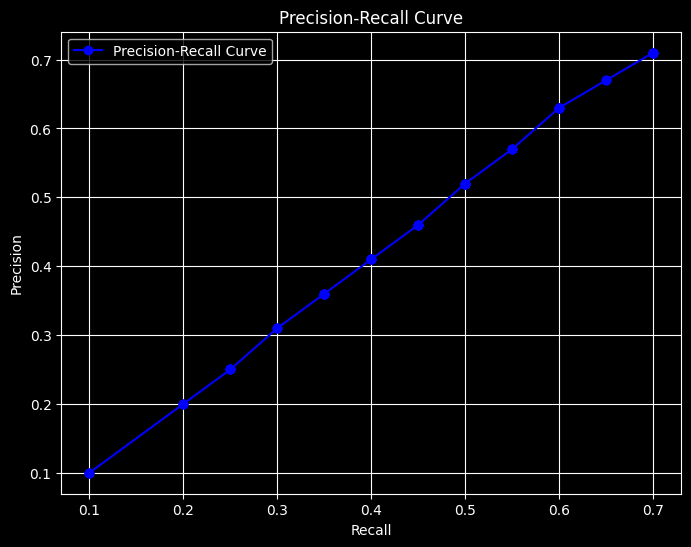

Actors Precision Recall Curve AUC: 0.24675000000000002
Best F1 Score: Precision: 0.4745539724826813; Recall: 0.46257391571998596; F1-score: 0.46848738193511963;


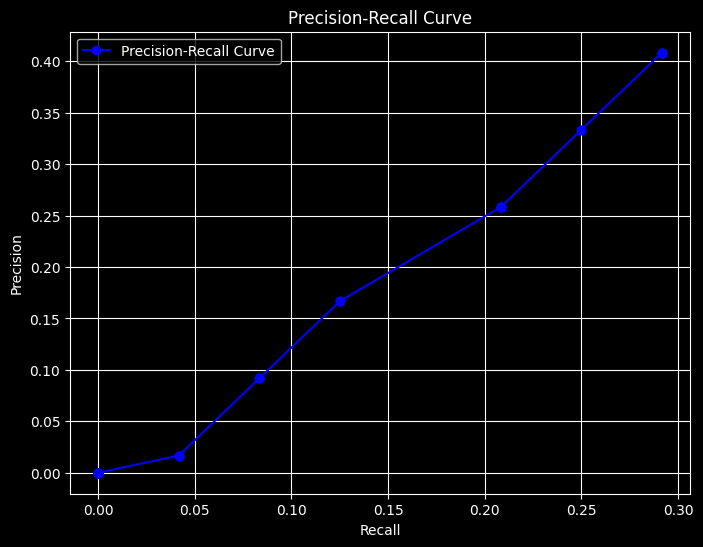

High Level Precision Recall Curve AUC: 0.053472222222222206
Best F1 Score: Precision: 0.19024738669395447; Recall: 0.14033041894435883; F1-score: 0.16152019798755646;


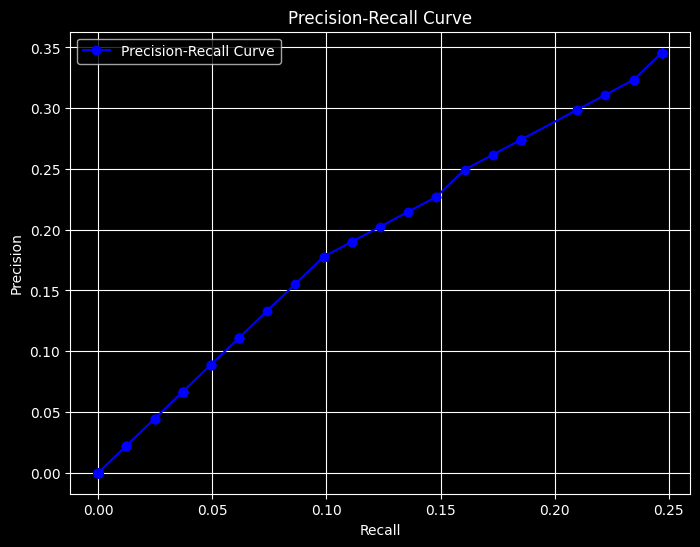

Low Level Goals Precision Recall Curve AUC: 0.047065996037189445
Best F1 Score: Precision: 0.14642783999443054; Recall: 0.09872446209192276; F1-score: 0.1179349347949028;


In [3]:
from src.evaluation.goal_evaluator import GoalEvaluator

PREPROCESSING = True #stop words remotion, stemming and lemmaization for the evaluation

evaluator_actors = GoalEvaluator(preprocess = False)
evaluator_hl = GoalEvaluator(preprocess = PREPROCESSING)
evaluator_ll = GoalEvaluator(preprocess = PREPROCESSING)

print("-----------------------------------------------------------")
print(f"{prompting_eval}, LLAMA ABLATION: {LLAMA_ABLATION_EVAL}, PREPROCESSING: {PREPROCESSING}")
print("-----------------------------------------------------------")

#----------------------------EVALUATION------------------------------------------------------

auc_prec_rec, best_f1 = evaluator_actors.print_prec_rec_curve(generated_actors_eval, manual_actors, output_file=f"{OUPUT_PATH}/actor_{SHOTS_NUMBER}.csv", save_to_file=True, rate_table=True)

print("Actors Precision Recall Curve AUC:", auc_prec_rec)
print(f"Best F1 Score: {best_f1}")

auc_prec_rec, best_f1 = evaluator_hl.print_prec_rec_curve(generated_hl_eval, manual_hl, output_file=f"{OUPUT_PATH}/hl_{SHOTS_NUMBER}.csv", save_to_file=True, rate_table=True)

print("High Level Precision Recall Curve AUC:", auc_prec_rec)
print(f"Best F1 Score: {best_f1}")

auc_prec_rec, best_f1 = evaluator_ll.print_prec_rec_curve(generated_ll_eval, manual_ll, output_file=f"{OUPUT_PATH}/ll_{SHOTS_NUMBER}.csv", save_to_file=True, rate_table=True)

print("Low Level Goals Precision Recall Curve AUC:", auc_prec_rec)
print(f"Best F1 Score: {best_f1}")

### APIs Extraction from Swagger

In [ ]:
print("API List STARTING...")
apiList = get_api_list_from_swagger(link=GROUNDTRUTH["swagger"])
print("API List DONE...")
print(apiList)

### APIs Mapping to Low Level Goals

In [ ]:
print("Mapping STARTING...")
mappings = generate_mapping_apis_goals(lowLevelGoals, apiList)
print("Mapping DONE")

In [ ]:
print(mappings[0].low_level_goal.high_level_associated.name)

### Mapping Table

In [ ]:
import json

print_api_goal_mapping(mappings)
with open(f"{OUPUT_PATH}/final_mapping_{SHOTS_NUMBER}.csv", "w") as f:
    f.write(json.dumps(mappings, default=lambda o: o.__dict__, indent=4))

Merging Results from Different Ground Truth

In [ ]:

from src.examples.shot_learning import ShotPromptingMode


import pandas as pd

def merge_csv_positional(path1, path2, w1, w2, output_path):
    # Leggi i file (usa il separatore che vedi nel file, es. ';')
    df1 = pd.read_csv(path1, sep=';')
    df2 = pd.read_csv(path2, sep=';')

    # Pulisci nomi colonne
    df1.columns = df1.columns.str.strip()
    df2.columns = df2.columns.str.strip()

    # Colonne numeriche su cui fare il calcolo
    cols_numeric = ['recall', 'fpr', 'f1_score', 'precision']

    # 1. Rimuovi eventuali spazi nelle celle
    # 2. Sostituisci virgola con punto (se usano formato italiano)
    # 3. Converti in numeri (i non-numeri diventano NaN)
    for col in cols_numeric:
        for df in [df1, df2]:
            if df[col].dtype == object:
                df[col] = df[col].astype(str).str.replace(',', '.').str.strip()
                df[col] = pd.to_numeric(df[col], errors='coerce')

    # Taglia alla lunghezza minima comune
    min_len = min(len(df1), len(df2))
    df1 = df1.iloc[:min_len].reset_index(drop=True)
    df2 = df2.iloc[:min_len].reset_index(drop=True)

    # Calcolo media pesata (gestisce i NaN se presenti)
    df_weighted = (df1[cols_numeric] * w1 + df2[cols_numeric] * w2) / (w1 + w2)

    # Ricostruisci il dataframe con 'th' del primo file
    df_result = pd.concat([df1[['th']], df_weighted], axis=1)

    # Salva
    df_result.to_csv(output_path, sep=',', index=False)
    print(f"Salvato: {output_path}")

# Esempio
# merge_csv_positional('file1.csv', 'file2.csv', 0.5, 0.5, 'output.csv')

def print_best_f1(path):
    df = pd.read_csv(path)
    # Trova la riga con il massimo f1_score
    best_row = df.loc[df['f1_score'].idxmax()]

    # Stampa formato "colonna: valore"
    for col, val in best_row.items():
        print(f"{col}: {val}")


import matplotlib.pyplot as plt

def plot_multi_roc(files, labels, title):
    plt.figure(figsize=(8, 6))

    # Itera su file e label accoppiati
    for f, lbl in zip(files, labels):
        df = pd.read_csv(f).sort_values(by='fpr')
        plt.plot(df['fpr'], df['recall'], label=lbl)

    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('FPR')
    plt.ylabel('Recall')
    plt.legend()
    plt.grid(True)
    plt.title(title)
    plt.show()


weights = {
    "actor": {
        "genome": 5,
        "gestao": 5
    },
    "hl": {
        "genome": 9,
        "gestao": 4
    },
    "ll": {
        "genome": 34,
        "gestao": 20
    }
}

for task in ["actor", "hl", "ll"]:
    file_names = []
    for prompting in [ShotPromptingMode.ZERO_SHOT, ShotPromptingMode.ONE_SHOT, ShotPromptingMode.FEW_SHOT]:

        file_name = f"{task}_{prompting}.csv"

        merge_csv_positional(f"../GENOME/{file_name}", f"../GESTAO/{file_name}", weights[task]["genome"], weights[task]["gestao"], f"output/{file_name}")

        print_best_f1(f"output/{file_name}")
        file_names.append(f"output/{file_name}")

    plot_multi_roc(file_names, ["Zero-shot", "One-shot", "Few-shot"], f"ROC for {task}")





